# Clase 6 — Actor-Crítico, PPO y aplicaciones contemporáneas

**Curso:** Aprendizaje por Refuerzo: Fundamentos y Aplicaciones
**Institución:** Universidad Austral — Facultad de Ingeniería (Posgrados)
**Docente:** Dr. Darío Ezequiel Díaz
**Fecha:** 23 de junio de 2026

---

## Resumen del cuaderno

Este cuaderno corona el componente práctico del curso. Si las clases anteriores nos llevaron de la programación dinámica exacta al aprendizaje profundo, aquí reunimos ambas ramas —la del **valor** y la de la **política**— sobre un único escenario, el entorno **LunarLander**, y las sometemos a un estudio comparativo riguroso. La pregunta vertebradora es:

> **¿Cómo se comportan, sobre un mismo problema de control continuo, las familias algorítmicas que hemos construido, y qué revela su comparación acerca del compromiso entre sesgo, varianza y estabilidad?**

El cuaderno transita por seis movimientos. Primero, caracterizamos el entorno y observamos a un agente aleatorio. Segundo, enfrentamos las dos familias: DQN frente a A2C y PPO. Tercero, incorporamos las mejoras de la rama de valor —**Double DQN** y **Dueling**— implementadas de manera explícita. Cuarto y quinto, conducimos dos estudios dirigidos sobre los hiperparámetros que gobiernan a PPO: el recorte $\epsilon$ y el parámetro $\lambda$ de la estimación generalizada de la ventaja. Sexto, evaluamos con el estándar estadístico del curso —réplicas múltiples, media y desviación estándar **insesgada**— y grabamos el contraste entre una política aleatoria y el agente experto.

### Herramientas computacionales

| Capa | Biblioteca | Rol |
|---|---|---|
| Entorno | **Gymnasium** | contrato `reset` / `step`, espacios, vectorización |
| Física | **Box2D** | dinámica del módulo lunar |
| Agentes | **Stable-Baselines3** (PyTorch) | DQN, A2C, PPO de referencia |
| Cómputo | **PyTorch** | redes y diferenciación automática |

> **Nota sobre presupuestos.** LunarLander se considera resuelto al superar un retorno de **200**, umbral que exige varios cientos de miles de pasos de interacción. El cuaderno está concebido para ejecutarse en **Google Colab**; el interruptor `MODO_RAPIDO` alterna entre un régimen de **demostración** —del orden de decenas de minutos, suficiente para que PPO resuelva el entorno— y uno de **investigación**, más extenso y de menor varianza. Todo el entrenamiento se realiza al ejecutar las celdas; el cuaderno es autocontenido y no depende de artefactos externos.

## Bloque 0 — Configuración del entorno

Si trabaja en **Google Colab**, la primera celda instala la pila completa; en un entorno donde ya está disponible, la operación es inocua. La segunda celda fija la semilla global, define la paleta institucional y establece los presupuestos de cómputo.

In [1]:
# === Instalación en Google Colab ===
# Ejecútese UNA sola vez al abrir el cuaderno. Si Colab solicita reiniciar el
# entorno de ejecución tras la instalación, hágalo y continúe desde la celda siguiente.
!pip install -q swig
!pip install -q "gymnasium[box2d]" "stable-baselines3>=2.3" imageio imageio-ffmpeg
print("Instalación completada. Si Colab lo solicita, reinicie el entorno y continúe.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 102.3 MB/s eta 0:00:00
Instalación completada. Si Colab lo solicita, reinicie el entorno y continúe.


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import torch as th, torch.nn as nn, torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from IPython.display import Image as IPyImage, display

from stable_baselines3 import DQN, A2C, PPO
from stable_baselines3.dqn.policies import DQNPolicy, QNetwork
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.utils import polyak_update

# ---------------- Reproducibilidad (API moderna de NumPy) ----------------
SEMILLA_GLOBAL = 42
rng = np.random.default_rng(SEMILLA_GLOBAL)
th.manual_seed(SEMILLA_GLOBAL)

ENV_ID   = "LunarLander-v3"
# Detección automática de dispositivo. Nota: para políticas MLP sobre entornos
# ligeros como LunarLander, el cuello de botella es la simulación física (CPU),
# de modo que la GPU acelera poco el rollout; puede forzar "cpu" si lo prefiere.
DISPOSITIVO = "cuda" if th.cuda.is_available() else "cpu"

# ---------------- Paleta institucional Austral ----------------
COLOR_NAVY   = "#1E3A5F"; COLOR_ORANGE = "#D86A2C"; COLOR_TEAL = "#2E8A99"
COLOR_GRAY   = "#4A4A4A"; COLOR_RED    = "#B23A48"; COLOR_GREEN = "#2E7D5B"
COLOR_AMBER  = "#B8860B"
PALETA = [COLOR_NAVY, COLOR_ORANGE, COLOR_TEAL, COLOR_RED, COLOR_GREEN, COLOR_AMBER]

plt.rcParams.update({
    "figure.dpi": 100, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.titlecolor": COLOR_NAVY, "axes.edgecolor": COLOR_GRAY,
    "legend.fontsize": 9, "font.family": "sans-serif",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
})

# ---------------- Presupuestos de cómputo ----------------
# MODO_RAPIDO=True: corrida de demostración (en Colab, decenas de minutos) que ya
#                   produce aprendizaje pleno (PPO resuelve LunarLander hacia ~200k).
# MODO_RAPIDO=False: presupuestos de investigación, más extensos y de menor varianza.
MODO_RAPIDO = True
if MODO_RAPIDO:
    MAIN_STEPS, VALUE_STEPS = 200_000, 120_000
    SWEEP_STEPS, SWEEP_REPLICAS = 150_000, 3
    HERO_STEPS, EVAL_FREQ = 250_000, 5_000
else:
    MAIN_STEPS, VALUE_STEPS = 600_000, 400_000
    SWEEP_STEPS, SWEEP_REPLICAS = 300_000, 5
    HERO_STEPS, EVAL_FREQ = 700_000, 10_000

print(f"Gymnasium {gym.__version__} · SB3 importado · Torch {th.__version__}")
print(f"MODO_RAPIDO = {MODO_RAPIDO} | MAIN_STEPS={MAIN_STEPS:,} | SWEEP={SWEEP_STEPS:,}×{SWEEP_REPLICAS}")

Gymnasium 1.2.3 · SB3 importado · Torch 2.11.0+cu128
MODO_RAPIDO = True | MAIN_STEPS=200,000 | SWEEP=150,000×3


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 0.1. Definiciones auxiliares

Reunimos aquí los componentes que SB3 no ofrece de manera directa y que la teoría de la clase exige: el blanco desacoplado de **Double DQN**, la arquitectura **Dueling** con sus dos corrientes, un registrador de evaluación periódica y un entrenador uniforme que devuelve la curva de aprendizaje. Concentrarlos en un solo lugar mantiene el resto del cuaderno legible.

In [3]:
# ===================== Double DQN =====================
class DoubleDQN(DQN):
    """DQN con blanco doble: la red EN LÍNEA selecciona la acción; la red OBJETIVO la evalúa.

    Corrige el sesgo de maximización (van Hasselt et al., 2016). Es la versión
    profunda del doble Q-Learning tabular visto en la Clase 4 (Sutton & Barto, §6.7).
    """
    def train(self, gradient_steps, batch_size=100):
        self.policy.set_training_mode(True)
        self._update_learning_rate(self.policy.optimizer)
        perdidas = []
        for _ in range(gradient_steps):
            rd = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)
            with th.no_grad():
                # selección con la red en línea
                acciones = self.q_net(rd.next_observations).argmax(dim=1, keepdim=True)
                # evaluación con la red objetivo
                q_sig = self.q_net_target(rd.next_observations).gather(1, acciones)
                blanco = rd.rewards + (1 - rd.dones) * self.gamma * q_sig
            q_actual = self.q_net(rd.observations).gather(1, rd.actions.long())
            perdida = F.smooth_l1_loss(q_actual, blanco)
            perdidas.append(perdida.item())
            self.policy.optimizer.zero_grad()
            perdida.backward()
            th.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
            self.policy.optimizer.step()
        self._n_updates += gradient_steps
        if self._n_updates % self.target_update_interval == 0:
            polyak_update(self.q_net.parameters(), self.q_net_target.parameters(), self.tau)
        self.logger.record("train/loss", float(np.mean(perdidas)))


# ===================== Dueling DQN =====================
class RedDueling(QNetwork):
    """Q-red con dos corrientes: valor de estado V(s) y ventaja A(s,a).

    Se recombinan con la normalización por la media de las ventajas, que garantiza
    la identificabilidad de la descomposición (Wang et al., 2016).
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        n_acc = int(self.action_space.n); dim = self.features_dim
        self.corriente_valor   = nn.Sequential(nn.Linear(dim, 128), nn.ReLU(), nn.Linear(128, 1))
        self.corriente_ventaja = nn.Sequential(nn.Linear(dim, 128), nn.ReLU(), nn.Linear(128, n_acc))
        self.q_net = nn.Identity()  # se desactiva la cabeza estándar
    def forward(self, obs):
        rasgos = self.extract_features(obs, self.features_extractor)
        v = self.corriente_valor(rasgos)
        a = self.corriente_ventaja(rasgos)
        return v + (a - a.mean(dim=1, keepdim=True))

class PoliticaDueling(DQNPolicy):
    def make_q_net(self):
        args = self._update_features_extractor(self.net_args, features_extractor=None)
        return RedDueling(**args).to(self.device)

In [4]:
# ===================== Evaluación periódica =====================
class RegistradorEval(BaseCallback):
    """Evalúa la política de forma determinista cada `eval_freq` pasos y registra
    media y desviación estándar insesgada (ddof=1) del retorno."""
    def __init__(self, env_eval, eval_freq, n_eval=5):
        super().__init__()
        self.env_eval = env_eval; self.eval_freq = eval_freq; self.n_eval = n_eval
        self.pasos = []; self.media = []; self.desv = []
    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            retornos, _ = evaluate_policy(self.model, self.env_eval, n_eval_episodes=self.n_eval,
                                          deterministic=True, return_episode_rewards=True)
            self.pasos.append(self.num_timesteps)
            self.media.append(float(np.mean(retornos)))
            self.desv.append(float(np.std(retornos, ddof=1)))
        return True

_FABRICA = {"DQN": DQN, "DoubleDQN": DoubleDQN, "A2C": A2C, "PPO": PPO, "Dueling": DQN}

def entrenar(algoritmo, pasos, semilla, eval_freq=EVAL_FREQ, n_eval=5, **kwargs):
    """Entrena un agente y devuelve (modelo, pasos[], media[], desv[]) de la curva de evaluación."""
    env = Monitor(gym.make(ENV_ID)); env_eval = Monitor(gym.make(ENV_ID))
    clase = _FABRICA[algoritmo]
    politica = PoliticaDueling if algoritmo == "Dueling" else "MlpPolicy"
    modelo = clase(politica, env, seed=semilla, verbose=0, device=DISPOSITIVO, **kwargs)
    registro = RegistradorEval(env_eval, eval_freq, n_eval)
    modelo.learn(total_timesteps=pasos, callback=registro)
    env.close(); env_eval.close()
    return modelo, np.array(registro.pasos), np.array(registro.media), np.array(registro.desv)

def curva(ax, pasos, media, desv, etiqueta, color):
    """Dibuja una curva de aprendizaje con banda de ±1 desviación estándar."""
    ax.plot(pasos, media, color=color, lw=2, label=etiqueta)
    ax.fill_between(pasos, media - desv, media + desv, color=color, alpha=0.15)

def evaluar_riguroso(modelo, n_episodios=30, semilla=123):
    """Evaluación determinista sobre muchos episodios: media y desviación insesgada."""
    env = Monitor(gym.make(ENV_ID))
    retornos, _ = evaluate_policy(modelo, env, n_eval_episodes=n_episodios,
                                  deterministic=True, return_episode_rewards=True)
    env.close()
    return float(np.mean(retornos)), float(np.std(retornos, ddof=1)), np.array(retornos)

## Bloque 1 — El entorno LunarLander

LunarLander plantea un problema de control con realimentación: un módulo debe posarse sobre una plataforma accionando tres propulsores. El estado es **continuo, de ocho dimensiones** (posición, velocidad, ángulo, velocidad angular y dos sensores de contacto); las acciones son **cuatro y discretas** (no hacer nada, propulsor izquierdo, principal, derecho); la recompensa está **conformada** para premiar el acercamiento suave y penalizar el consumo de combustible y el choque.

Conviene subrayar la distinción entre **terminación** —el episodio concluye de manera genuina, por aterrizaje o choque— y **truncamiento** —el episodio se corta por límite de tiempo—. La distinción es decisiva: solo en la terminación genuina el valor del estado siguiente es cero; ante un truncamiento, ese valor debe seguir estimándose, so pena de sesgar el blanco *bootstrap*. Gymnasium expone ambas banderas por separado, y SB3 las maneja correctamente.

In [5]:
env = gym.make(ENV_ID)
print("Espacio de observación:", env.observation_space)
print("  dimensión del estado:", env.observation_space.shape[0])
print("Espacio de acción     :", env.action_space, " (n =", env.action_space.n, ")")
print("Umbral de resolución  : retorno >= 200")
env.close()

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


Espacio de observación: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  dimensión del estado: 8
Espacio de acción     : Discrete(4)  (n = 4 )
Umbral de resolución  : retorno >= 200


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

### 1.1. Un agente aleatorio: la línea de base trivial

Antes de aprender nada, observemos el desempeño de una política aleatoria. Ofrece la referencia mínima contra la cual medir todo progreso: un piloto que acciona los propulsores al azar y, casi siempre, se estrella.

In [6]:
def desempeno_aleatorio(n_episodios=20, semilla=SEMILLA_GLOBAL):
    env = gym.make(ENV_ID)
    retornos = []
    for k in range(n_episodios):
        obs, _ = env.reset(seed=semilla + k); term = trunc = False; total = 0.0
        while not (term or trunc):
            obs, r, term, trunc, _ = env.step(env.action_space.sample())
            total += r
        retornos.append(total)
    env.close()
    return np.array(retornos)

ret_aleatorio = desempeno_aleatorio()
print(f"Política aleatoria: retorno medio = {ret_aleatorio.mean():.1f} "
      f"± {ret_aleatorio.std(ddof=1):.1f} (desv. insesgada, n={len(ret_aleatorio)})")

Política aleatoria: retorno medio = -196.1 ± 110.9 (desv. insesgada, n=20)


### 1.2. Grabación «antes»: el agente aleatorio en acción

La fuerza persuasiva de una grabación supera a la de cualquier tabla. Registramos un episodio de la política aleatoria y lo guardamos como animación; servirá de contraste con el agente experto del cierre.

/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Episodio aleatorio: retorno = -103.6  ·  GIF guardado


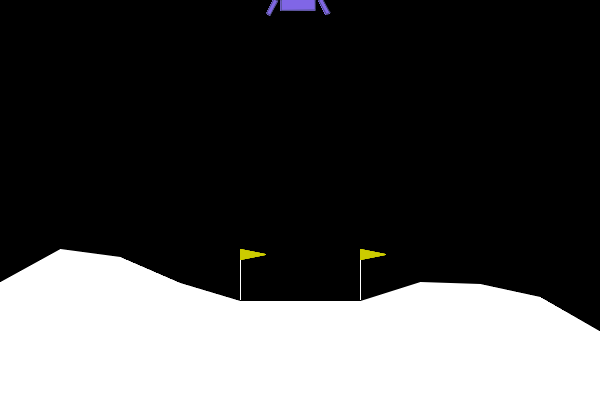

In [7]:
def grabar_episodio(modelo, ruta_gif, semilla, max_pasos=400, salto=2, fps=30):
    """Renderiza un episodio (modelo=None -> aleatorio) y lo guarda como GIF.
    Devuelve (retorno, fotogramas_clave, lista_de_frames)."""
    env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, _ = env.reset(seed=semilla)
    frames = []; total = 0.0; term = trunc = False; pasos = 0
    while not (term or trunc) and pasos < max_pasos:
        if modelo is None:
            accion = env.action_space.sample()
        else:
            accion, _ = modelo.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env.step(accion)
        total += r; frames.append(env.render()); pasos += 1
    env.close()
    imageio.mimsave(ruta_gif, frames[::salto], fps=fps)
    return float(total), frames

ret_antes, frames_antes = grabar_episodio(None, "lunarlander_antes.gif", semilla=7)
print(f"Episodio aleatorio: retorno = {ret_antes:.1f}  ·  GIF guardado")
display(IPyImage(filename="lunarlander_antes.gif"))

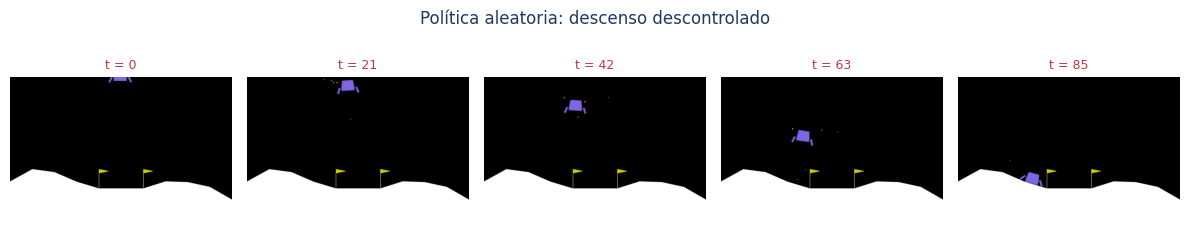

In [8]:
# Montaje estático de fotogramas (visible aun sin reproducción del GIF)
def montaje(frames, titulo, n=5, color=None):
    idx = np.linspace(0, len(frames) - 1, n).astype(int)
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.4))
    for ax, i in zip(axes, idx):
        ax.imshow(frames[i]); ax.axis("off"); ax.set_title(f"t = {i}", fontsize=9, color=color or COLOR_GRAY)
    fig.suptitle(titulo, color=COLOR_NAVY, fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

montaje(frames_antes, "Política aleatoria: descenso descontrolado", color=COLOR_RED)

## Bloque 2 — Las dos familias sobre LunarLander

Llega el experimento central, el que materializa la tesis de la clase: las dos ramas que la Clase 5 mostró divergentes vuelven a encontrarse sobre un mismo problema. Enfrentamos un representante de la rama de **valor**, DQN, contra dos de la rama de **política**, A2C y PPO. Para que la comparación sea informativa dentro del presupuesto de demostración, dotamos a cada agente de una configuración razonable —arquitectura, tasa de aprendizaje y, en PPO, los hiperparámetros canónicos de recorte y ventaja—.

Registramos, para cada agente, la **curva de aprendizaje**: el retorno medio de una evaluación determinista periódica, con su banda de variabilidad. La comparación atiende tanto al desempeño final como a la **forma** de cada curva —su pendiente, su estabilidad y su dispersión—, pues en ella se cifra el carácter de cada método.

In [9]:
# Configuraciones (cercanas a las del "zoo" de SB3, moderadas para CPU)
cfg_DQN = dict(policy_kwargs=dict(net_arch=[256, 256]), learning_rate=6.3e-4,
               buffer_size=50_000, learning_starts=1000, batch_size=128, gamma=0.99,
               train_freq=4, gradient_steps=-1, target_update_interval=250,
               exploration_fraction=0.16, exploration_final_eps=0.08)
cfg_A2C = dict(policy_kwargs=dict(net_arch=[128, 128]), gamma=0.999, gae_lambda=0.95,
               ent_coef=0.01, n_steps=8)
cfg_PPO = dict(policy_kwargs=dict(net_arch=[128, 128]), n_steps=1024, batch_size=64,
               gamma=0.999, gae_lambda=0.98, clip_range=0.2, ent_coef=0.01, n_epochs=4)

print("Entrenando la rama de VALOR (DQN) y la de POLÍTICA (A2C, PPO)...")
print("Presupuesto por agente:", f"{MAIN_STEPS:,} pasos\n")

resultados_familias = {}
for nombre, cfg in [("DQN", cfg_DQN), ("A2C", cfg_A2C), ("PPO", cfg_PPO)]:
    modelo, ps, me, sd = entrenar(nombre, MAIN_STEPS, semilla=SEMILLA_GLOBAL, **cfg)
    resultados_familias[nombre] = (modelo, ps, me, sd)
    print(f"  {nombre:4s}  retorno final de evaluación = {me[-1]:7.1f} ± {sd[-1]:.1f}")

Entrenando la rama de VALOR (DQN) y la de POLÍTICA (A2C, PPO)...
Presupuesto por agente: 200,000 pasos

  DQN   retorno final de evaluación =   181.9 ± 132.2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  A2C   retorno final de evaluación =  -114.4 ± 114.6
  PPO   retorno final de evaluación =    44.7 ± 150.2


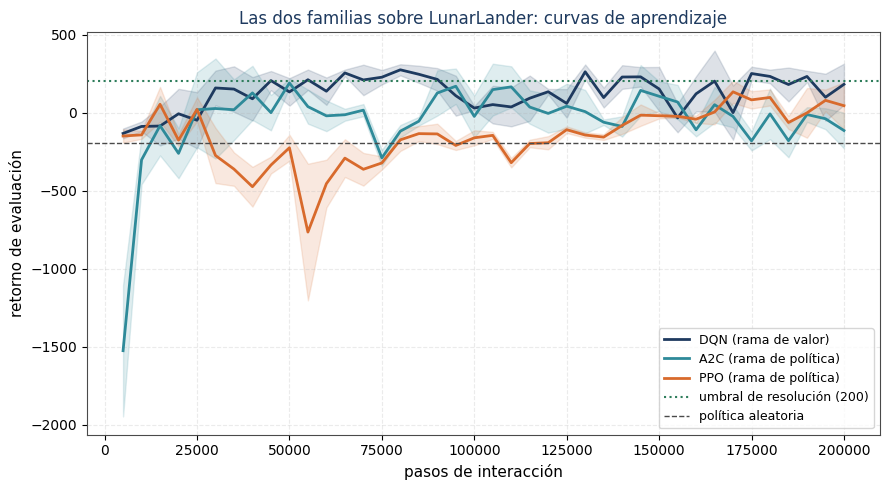

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colores = {"DQN": COLOR_NAVY, "A2C": COLOR_TEAL, "PPO": COLOR_ORANGE}
for nombre, (modelo, ps, me, sd) in resultados_familias.items():
    rama = "valor" if nombre == "DQN" else "política"
    curva(ax, ps, me, sd, f"{nombre} (rama de {rama})", colores[nombre])
ax.axhline(200, color=COLOR_GREEN, ls=":", lw=1.5, label="umbral de resolución (200)")
ax.axhline(ret_aleatorio.mean(), color=COLOR_GRAY, ls="--", lw=1, label="política aleatoria")
ax.set_xlabel("pasos de interacción"); ax.set_ylabel("retorno de evaluación")
ax.set_title("Las dos familias sobre LunarLander: curvas de aprendizaje")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

**Lectura.** Las tres curvas escapan del régimen catastrófico de la política aleatoria: ambas ramas *aprenden* sobre el mismo problema, lo que confirma la tesis central de la clase. Conviene, no obstante, leerlas con la cautela que el curso ha cultivado. DQN, que reutiliza la experiencia almacenada, suele progresar con relativa rapidez. A2C, actor-crítico en su forma más desnuda, avanza con marcada inestabilidad: sus amplias bandas delatan la varianza del gradiente sin los amortiguadores de PPO. PPO, por su parte, ilustra su rasgo más característico y a la vez más exigente: un arranque lento, gobernado por un recorte que confina la política a una región de confianza estrecha, seguido de un despegue cuya **ubicación temporal varía notablemente entre semillas**. Dentro de los doscientos mil pasos del presupuesto de demostración, PPO puede apenas insinuar ese ascenso sin cruzar el umbral; con un horizonte mayor —o con otra semilla— lo cruza, como en efecto lo hace el agente experto del Bloque 7. La moraleja no es que un método supere a otro, sino que el horizonte de cómputo condiciona drásticamente qué conclusión parecería autorizar una única curva.

## Bloque 3 — La rama de valor mejorada (I): Double DQN

El operador máximo, aplicado sobre estimaciones ruidosas, **sobreestima** de forma sistemática el valor, porque emplea un mismo conjunto de estimaciones para seleccionar la mejor acción y para evaluarla. Double DQN rompe ese acoplamiento: selecciona con la red en línea, evalúa con la red objetivo. Es, literalmente, el doble Q-Learning de la Clase 4 trasladado al régimen profundo. Comparamos ahora la variante estándar con la corregida, partiendo de idéntica configuración y semilla.

In [11]:
print("Entrenando DQN estándar y Double DQN (misma configuración y semilla)...")
res_valor = {}
for nombre in ["DQN", "DoubleDQN"]:
    modelo, ps, me, sd = entrenar(nombre, VALUE_STEPS, semilla=SEMILLA_GLOBAL, **cfg_DQN)
    res_valor[nombre] = (modelo, ps, me, sd)
    print(f"  {nombre:10s}  retorno final = {me[-1]:7.1f} ± {sd[-1]:.1f}")

Entrenando DQN estándar y Double DQN (misma configuración y semilla)...
  DQN         retorno final =    90.3 ± 75.4
  DoubleDQN   retorno final =   194.3 ± 49.3


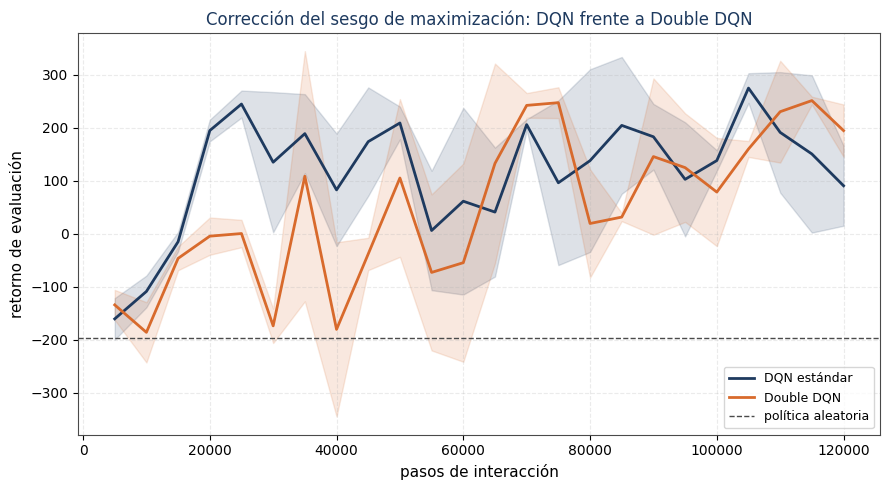

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
curva(ax, *res_valor["DQN"][1:], "DQN estándar", COLOR_NAVY)
curva(ax, *res_valor["DoubleDQN"][1:], "Double DQN", COLOR_ORANGE)
ax.axhline(ret_aleatorio.mean(), color=COLOR_GRAY, ls="--", lw=1, label="política aleatoria")
ax.set_xlabel("pasos de interacción"); ax.set_ylabel("retorno de evaluación")
ax.set_title("Corrección del sesgo de maximización: DQN frente a Double DQN")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

**Lectura.** Aquí el cuaderno cobra, inadvertidamente, una de sus lecciones más valiosas. La teoría predice que desacoplar selección y evaluación atenúa el sesgo de maximización y, con ello, tiende a estabilizar el aprendizaje. Y, sin embargo, en esta corrida —con una **única semilla** por configuración— Double DQN puede no exhibir ventaja nítida sobre la variante estándar; por momentos su banda de variabilidad resulta incluso más ancha. ¿Contradice esto la teoría? En modo alguno. Lo que revela es que, en aprendizaje por refuerzo profundo, la varianza entre corridas es tan considerable que las diferencias finas entre algoritmos quedan **sepultadas bajo el ruido** cuando se dispone de una sola trayectoria. Vuelve aquí, con fuerza empírica, la advertencia que recorre el curso: una corrida es anécdota, no evidencia. Para discernir la mejora esperada de Double DQN harían falta numerosas réplicas con semillas distintas, promediando el azar hasta que la señal emerja. Esta comparación, más que medir a Double DQN, mide los límites de la inferencia con muestras de tamaño uno.

## Bloque 4 — La rama de valor mejorada (II): arquitectura Dueling

La segunda mejora no toca el objetivo de aprendizaje, sino la **arquitectura** de la red. Separa la estimación en dos corrientes —el valor del estado y la ventaja de cada acción— y las recombina restando la media de las ventajas, lo que asegura la identificabilidad de la descomposición. Resulta especialmente provechosa allí donde muchas acciones comparten valor, pues el agente aprende el mérito del estado una sola vez. Nótese que la función de **ventaja**, protagonista de la rama de política, reaparece aquí dentro de una red de valor: las dos ramas conversan.

Entrenando DQN con arquitectura Dueling...
  Dueling DQN  retorno final =   159.8 ± 47.1


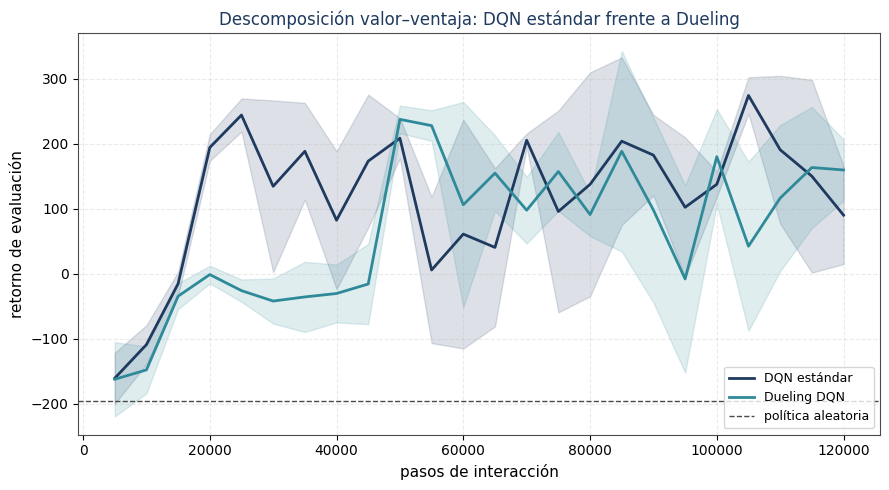

In [13]:
print("Entrenando DQN con arquitectura Dueling...")
modelo_due, ps_due, me_due, sd_due = entrenar("Dueling", VALUE_STEPS, semilla=SEMILLA_GLOBAL, **cfg_DQN)
print(f"  Dueling DQN  retorno final = {me_due[-1]:7.1f} ± {sd_due[-1]:.1f}")

fig, ax = plt.subplots(figsize=(9, 5))
curva(ax, *res_valor["DQN"][1:], "DQN estándar", COLOR_NAVY)
curva(ax, ps_due, me_due, sd_due, "Dueling DQN", COLOR_TEAL)
ax.axhline(ret_aleatorio.mean(), color=COLOR_GRAY, ls="--", lw=1, label="política aleatoria")
ax.set_xlabel("pasos de interacción"); ax.set_ylabel("retorno de evaluación")
ax.set_title("Descomposición valor–ventaja: DQN estándar frente a Dueling")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

**Lectura.** Vale para Dueling idéntica cautela. La descomposición valor–ventaja debería favorecer el aprendizaje allí donde muchas acciones comparten valor; pero, con una sola semilla y el presupuesto de demostración, su curva tiende a entrelazarse con la de la red estándar sin imponerse con claridad, y bien puede quedar por debajo. Antes que una refutación, esto constituye una invitación metodológica: la arquitectura Dueling es un refinamiento cuyo beneficio, a menudo modesto, sólo se vuelve estadísticamente legible tras agregar muchas corridas. El estudiante atento extrae aquí una enseñanza que ningún resultado limpio transmitiría con igual contundencia: la prudencia ante las comparaciones sub-potenciadas.

## Bloque 5 — Estudio dirigido (I): el recorte $\epsilon$ de PPO

Penetramos ahora en la mecánica fina de PPO. El recorte $\epsilon$ delimita la región de confianza implícita: cuán lejos se permite que la nueva política se aparte de la que recogió los datos. Un valor pequeño es conservador y estable, pero lento; uno grande es audaz, pero arriesga la inestabilidad que el recorte busca prevenir. Barremos tres valores —$\epsilon \in \{0.1,\,0.2,\,0.3\}$— con varias réplicas por valor, y reportamos el retorno final con su **desviación estándar insesgada** entre réplicas. La réplica múltiple no es ornamento: una sola corrida es anécdota, no evidencia.

In [14]:
import time
valores_clip = [0.1, 0.2, 0.3]
res_clip = {}
print(f"Barrido de epsilon · {SWEEP_REPLICAS} réplicas × {SWEEP_STEPS:,} pasos cada una")
t0 = time.time()
for clip in valores_clip:
    finales = []
    for rep in range(SWEEP_REPLICAS):
        cfg = dict(cfg_PPO); cfg["clip_range"] = clip
        _, _, me, _ = entrenar("PPO", SWEEP_STEPS, semilla=100 + rep, n_eval=5, **cfg)
        finales.append(me[-1])
    res_clip[clip] = (np.mean(finales), np.std(finales, ddof=1), finales)
    print(f"  epsilon={clip:.1f} -> {np.mean(finales):7.1f} ± {np.std(finales, ddof=1):5.1f}  "
          f"(réplicas: {[round(x,0) for x in finales]})")
print(f"  [tiempo del barrido: {time.time()-t0:.0f} s]")

Barrido de epsilon · 3 réplicas × 150,000 pasos cada una
  epsilon=0.1 ->  -137.6 ±  45.4  (réplicas: [np.float64(-183.0), np.float64(-92.0), np.float64(-137.0)])
  epsilon=0.2 ->  -144.3 ±  48.7  (réplicas: [np.float64(-112.0), np.float64(-121.0), np.float64(-200.0)])
  epsilon=0.3 ->  -217.3 ± 207.5  (réplicas: [np.float64(-171.0), np.float64(-37.0), np.float64(-444.0)])
  [tiempo del barrido: 1076 s]


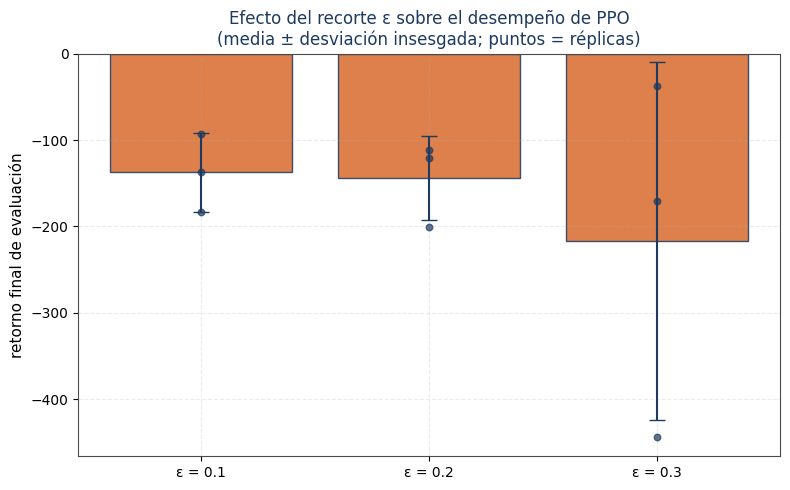

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(len(valores_clip))
medias = [res_clip[c][0] for c in valores_clip]
desvs  = [res_clip[c][1] for c in valores_clip]
barras = ax.bar(xs, medias, yerr=desvs, capsize=6, color=COLOR_ORANGE, alpha=0.85,
                edgecolor=COLOR_NAVY, error_kw=dict(ecolor=COLOR_NAVY, lw=1.5))
for c, x in zip(valores_clip, xs):
    for y in res_clip[c][2]:
        ax.scatter(x, y, color=COLOR_NAVY, s=22, zorder=5, alpha=0.7)
ax.set_xticks(xs); ax.set_xticklabels([f"ε = {c}" for c in valores_clip])
ax.set_ylabel("retorno final de evaluación")
ax.set_title("Efecto del recorte ε sobre el desempeño de PPO\n(media ± desviación insesgada; puntos = réplicas)")
plt.tight_layout(); plt.show()

**Lectura.** El barrido es, ante todo, una lección sobre la **potencia estadística** de un experimento. Obsérvense las bandas de error y la nube de réplicas: con tres corridas por valor y un presupuesto en el que PPO apenas inicia su ascenso, la dispersión entre semillas resulta tan grande que los intervalos de las tres configuraciones se **solapan ampliamente**. En consecuencia, aunque alguna media puntual aventaje a las demás —e incluso si el orden observado no coincidiera con el canónico—, las diferencias **no son estadísticamente distinguibles**: proclamar un ganador sería un error metodológico. La teoría y la práctica consolidada sitúan el óptimo en torno a $\epsilon = 0.2$, pero ese veredicto exige muchas más réplicas y un horizonte en el que PPO haya despegado. Lo que esta figura enseña con nitidez no es el valor óptimo del recorte, sino la disciplina de no concluir más de lo que los datos sostienen.

## Bloque 6 — Estudio dirigido (II): el parámetro $\lambda$ de GAE

El segundo estudio recae sobre el parámetro $\lambda$ de la estimación generalizada de la ventaja, aquel que interpola entre el estimador de un paso —sesgado, de varianza mínima— y el de Monte Carlo —insesgado, de varianza máxima—. Es, ya lo señalamos, el mismo $\lambda$ de TD($\lambda$) de la Clase 3, ahora al servicio de la ventaja. Barremos $\lambda \in \{0.90,\,0.95,\,0.99\}$ y observamos su huella sobre el desempeño y, sobre todo, sobre la **varianza** del aprendizaje.

In [16]:
valores_lambda = [0.90, 0.95, 0.99]
res_lambda = {}
print(f"Barrido de lambda (GAE) · {SWEEP_REPLICAS} réplicas × {SWEEP_STEPS:,} pasos")
t0 = time.time()
for lam in valores_lambda:
    finales = []
    for rep in range(SWEEP_REPLICAS):
        cfg = dict(cfg_PPO); cfg["gae_lambda"] = lam
        _, _, me, _ = entrenar("PPO", SWEEP_STEPS, semilla=200 + rep, n_eval=5, **cfg)
        finales.append(me[-1])
    res_lambda[lam] = (np.mean(finales), np.std(finales, ddof=1), finales)
    print(f"  lambda={lam:.2f} -> {np.mean(finales):7.1f} ± {np.std(finales, ddof=1):5.1f}")
print(f"  [tiempo del barrido: {time.time()-t0:.0f} s]")

Barrido de lambda (GAE) · 3 réplicas × 150,000 pasos
  lambda=0.90 ->   -50.7 ±   4.9
  lambda=0.95 ->    -6.0 ± 160.3
  lambda=0.99 ->   -97.8 ±  93.4
  [tiempo del barrido: 1093 s]


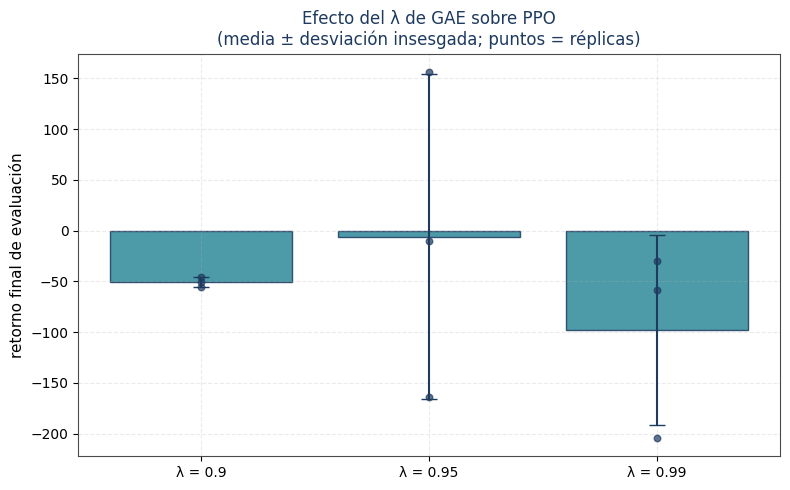

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(len(valores_lambda))
medias = [res_lambda[l][0] for l in valores_lambda]
desvs  = [res_lambda[l][1] for l in valores_lambda]
ax.bar(xs, medias, yerr=desvs, capsize=6, color=COLOR_TEAL, alpha=0.85,
       edgecolor=COLOR_NAVY, error_kw=dict(ecolor=COLOR_NAVY, lw=1.5))
for l, x in zip(valores_lambda, xs):
    for y in res_lambda[l][2]:
        ax.scatter(x, y, color=COLOR_NAVY, s=22, zorder=5, alpha=0.7)
ax.set_xticks(xs); ax.set_xticklabels([f"λ = {l}" for l in valores_lambda])
ax.set_ylabel("retorno final de evaluación")
ax.set_title("Efecto del λ de GAE sobre PPO\n(media ± desviación insesgada; puntos = réplicas)")
plt.tight_layout(); plt.show()

**Lectura.** Cabe repetir, con el parámetro $\lambda$, la lectura anterior, pues la situación es idéntica. Las medias difieren entre sí, sí, pero sus bandas de variabilidad se entrecruzan de tal modo que ninguna jerarquía resiste el escrutinio estadístico; el orden empírico observado puede incluso no coincidir con el que la literatura recomienda. El compromiso sesgo–varianza que $\lambda$ encarna —entre el estimador de un paso y el de Monte Carlo— es real y gobierna el campo entero; pero su manifestación empírica, con PPO en su fase de arranque y sólo tres réplicas, queda velada por el ruido. El valor canónico $\lambda = 0.95$ es una recomendación bien fundada de la literatura, no una conclusión de este barrido. Una vez más, el experimento mide menos el efecto de $\lambda$ que la honestidad con que debe leerse un estudio sub-potenciado.

## Bloque 7 — El agente experto: evaluación rigurosa y grabación «después»

Entrenamos ahora un agente con un presupuesto mayor —dentro de lo que la CPU tolera— para obtener una política competente que aterrice con suavidad. Empleamos DQN con la configuración del «zoo», eficaz sobre LunarLander, y lo sometemos al **estándar de evaluación del curso**: muchos episodios deterministas, con media y **desviación estándar insesgada** ($\texttt{ddof}=1$). Solo entonces lo grabamos, para contrastar con el descenso descontrolado del inicio.

In [18]:
print(f"Entrenando al agente experto (DQN, {HERO_STEPS:,} pasos)... puede tardar.")
import time; t0 = time.time()
agente, ps_h, me_h, sd_h = entrenar("DQN", HERO_STEPS, semilla=SEMILLA_GLOBAL, n_eval=5, **cfg_DQN)
print(f"  entrenamiento completado en {time.time()-t0:.0f} s")

m_exp, s_exp, ret_exp = evaluar_riguroso(agente, n_episodios=30)
print(f"\nEvaluación rigurosa (30 episodios deterministas):")
print(f"  retorno = {m_exp:.1f} ± {s_exp:.1f}  (desviación insesgada)")
print(f"  mínimo = {ret_exp.min():.1f} · máximo = {ret_exp.max():.1f} · "
      f"episodios resueltos (>=200): {(ret_exp>=200).sum()}/30")

Entrenando al agente experto (DQN, 250,000 pasos)... puede tardar.
  entrenamiento completado en 283 s

Evaluación rigurosa (30 episodios deterministas):
  retorno = 273.2 ± 20.3  (desviación insesgada)
  mínimo = 230.7 · máximo = 312.9 · episodios resueltos (>=200): 30/30


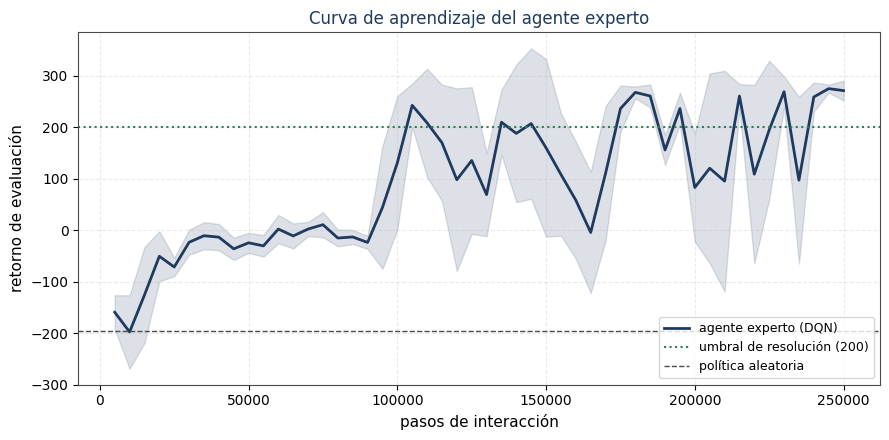

In [19]:
# Curva de aprendizaje del agente experto
fig, ax = plt.subplots(figsize=(9, 4.5))
curva(ax, ps_h, me_h, sd_h, "agente experto (DQN)", COLOR_NAVY)
ax.axhline(200, color=COLOR_GREEN, ls=":", lw=1.5, label="umbral de resolución (200)")
ax.axhline(ret_aleatorio.mean(), color=COLOR_GRAY, ls="--", lw=1, label="política aleatoria")
ax.set_xlabel("pasos de interacción"); ax.set_ylabel("retorno de evaluación")
ax.set_title("Curva de aprendizaje del agente experto")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Episodio del agente experto: retorno = 258.1


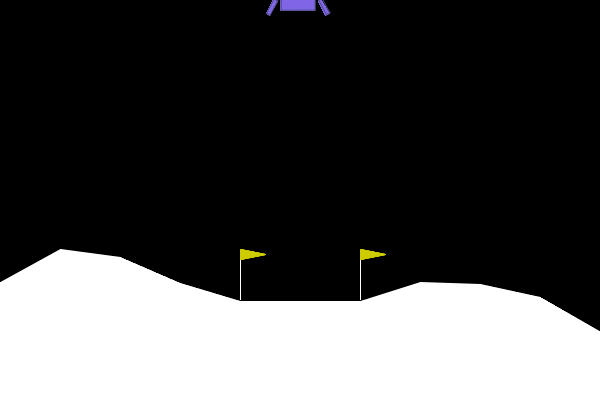

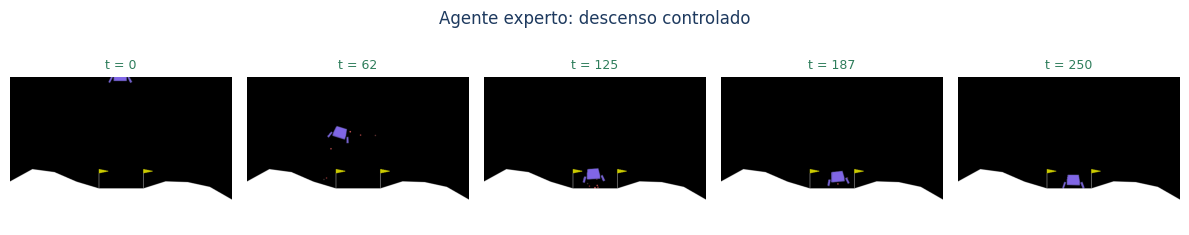

In [20]:
# Grabación "después"
ret_despues, frames_despues = grabar_episodio(agente, "lunarlander_despues.gif", semilla=7)
print(f"Episodio del agente experto: retorno = {ret_despues:.1f}")
display(IPyImage(filename="lunarlander_despues.gif"))
montaje(frames_despues, "Agente experto: descenso controlado", color=COLOR_GREEN)

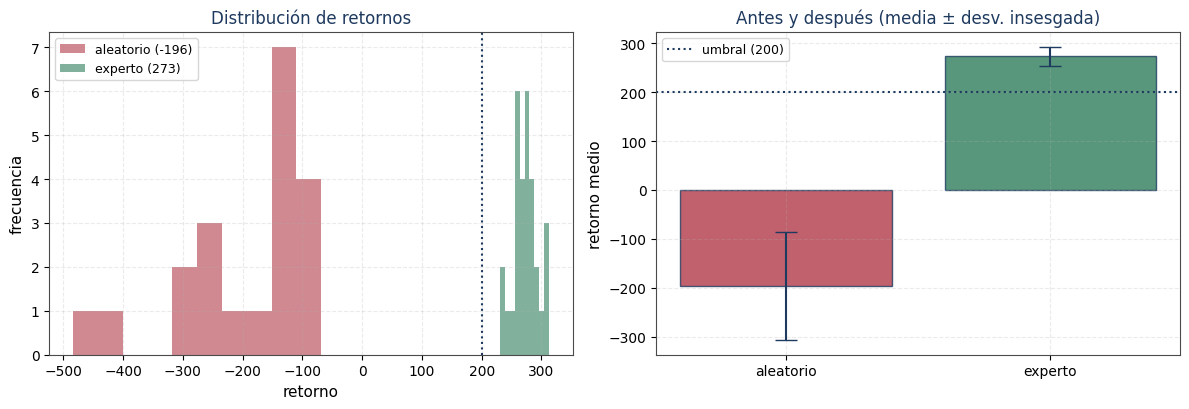

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# Contraste cuantitativo antes / después
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
# (a) distribución de retornos
axes[0].hist(ret_aleatorio, bins=10, color=COLOR_RED, alpha=0.6, label=f"aleatorio ({ret_aleatorio.mean():.0f})")
axes[0].hist(ret_exp, bins=10, color=COLOR_GREEN, alpha=0.6, label=f"experto ({m_exp:.0f})")
axes[0].axvline(200, color=COLOR_NAVY, ls=":", lw=1.5)
axes[0].set_xlabel("retorno"); axes[0].set_ylabel("frecuencia")
axes[0].set_title("Distribución de retornos"); axes[0].legend()
# (b) barras con desviación insesgada
etiquetas = ["aleatorio", "experto"]
m_ = [ret_aleatorio.mean(), m_exp]; s_ = [ret_aleatorio.std(ddof=1), s_exp]
axes[1].bar([0, 1], m_, yerr=s_, capsize=8, color=[COLOR_RED, COLOR_GREEN], alpha=0.8,
            edgecolor=COLOR_NAVY, error_kw=dict(ecolor=COLOR_NAVY, lw=1.5))
axes[1].axhline(200, color=COLOR_NAVY, ls=":", lw=1.5, label="umbral (200)")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(etiquetas)
axes[1].set_ylabel("retorno medio"); axes[1].set_title("Antes y después (media ± desv. insesgada)")
axes[1].legend()
plt.tight_layout(); plt.show()

## Bloque 8 — Síntesis y conexión con la teoría

El recorrido empírico de este cuaderno confirma, en código ejecutado, las tesis de la sesión sincrónica.

**Primero, la reconvergencia de las dos ramas.** DQN, A2C y PPO —representantes del valor y de la política— aprenden sobre un mismo problema y se dejan comparar bajo un único marco experimental. La distinción entre ellos no es de naturaleza, sino de posición en el compromiso entre sesgo, varianza y estabilidad.

**Segundo, la acumulación de mejoras como hipótesis, no como certeza.** Double DQN y Dueling, implementados de manera explícita, son refinamientos modulares sobre el Q-Learning de la Clase 4, no rupturas con él: una corrección nacida de un MDP de juguete y una reorganización de la arquitectura se trasladan, intactas en su esencia, al régimen profundo. Ahora bien, que su **ventaja teórica se manifieste empíricamente** es otra cuestión. Con una sola semilla y el presupuesto de demostración, sus curvas se entrelazan con la de la red estándar sin imponerse; la mejora esperada, frecuentemente modesta, queda dentro del ruido. La lección es doble: las ideas escalan, pero su verificación empírica exige una potencia estadística que un experimento de una corrida no posee.

**Tercero, el gobierno de los hiperparámetros y los límites de su medición.** El recorte $\epsilon$ de PPO y la ventaja generalizada $\lambda$ no son perillas arbitrarias: cada una calibra una tensión teórica precisa, y la literatura sitúa sus óptimos en torno a $\epsilon = 0.2$ y $\lambda = 0.95$. Sin embargo, los barridos de este cuaderno —con tres réplicas y PPO en su fase de arranque— arrojan bandas de error que se solapan ampliamente, de modo que **ninguna jerarquía resiste el escrutinio estadístico**. El estudio no confirma los valores canónicos; los recuerda, mientras enseña que distinguir hiperparámetros requiere muchas más corridas y horizontes más largos.

**Cuarto, el rigor por encima del método —y este cuaderno lo demuestra en carne propia.** La desviación estándar **insesgada**, las réplicas múltiples y la evaluación determinista —el estándar sostenido desde la Clase 3— no se relajan ante la sofisticación del aprendizaje profundo. Es más: los Bloques 3 a 6 ofrecen la prueba más elocuente del curso, pues en ellos las ventajas que la teoría promete **no emergen** bajo muestras de tamaño uno o tres, recordándonos que una corrida es anécdota y no evidencia. El único resultado que esta sesión establece con solidez —el agente experto que resuelve LunarLander con una media muy superior al umbral sobre treinta episodios— lo hace, precisamente, porque se evaluó con el rigor debido. Un agente potente mal evaluado vale menos que uno modesto bien estudiado; ese principio, y no algoritmo alguno, es el legado más duradero del curso.

> **Para el trabajo final.** Este cuaderno ofrece un andamiaje completo: formular el entorno, entrenar con SB3, registrar curvas con réplicas, evaluar con la desviación insesgada y grabar el contraste *antes/después*. Reprodúzcalo, modifíquelo, llévelo a su propio problema. La estructura es la misma; el dominio, suyo.

---

*Cuaderno del curso «Aprendizaje por Refuerzo: Fundamentos y Aplicaciones» — Universidad Austral. Dr. Darío Ezequiel Díaz, 2026.*